Full dataset shape: (6607, 7)
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             23          84            7               73                  0   
1             19          64            8               59                  2   
2             24          98            7               91                  2   
3             29          89            8               98                  1   
4             19          92            6               65                  3   

   Physical_Activity  Exam_Score  
0                  3          67  
1                  4          61  
2                  4          74  
3                  4          71  
4                  4          70  

Pass/Fail threshold: 65

Label counts:
Label
1    5155
0    1452
Name: count, dtype: int64

Modified dataset: 
    Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             23          84            7               73                  0  

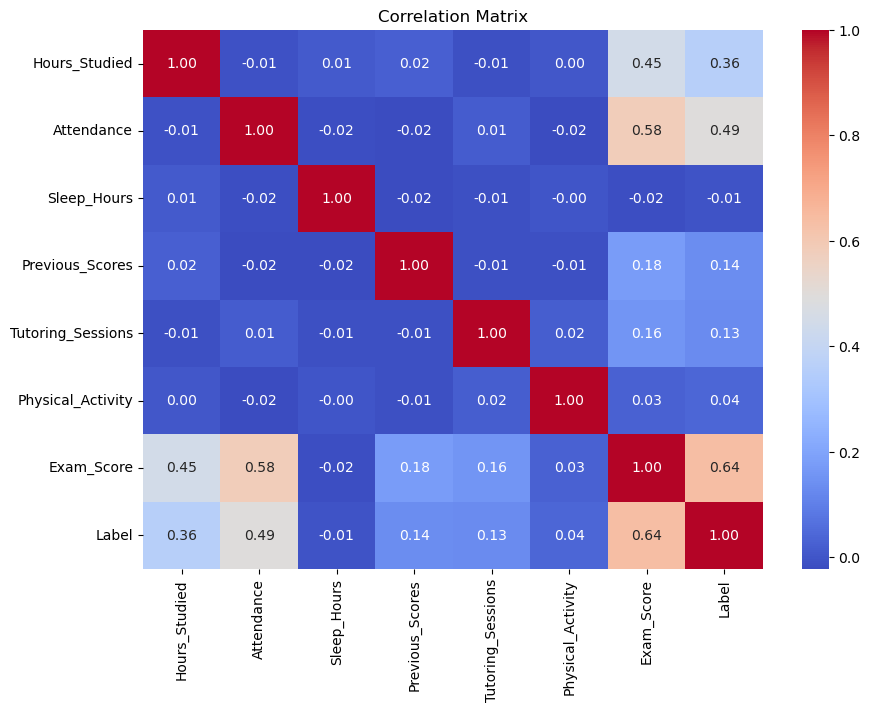


X_train shape: (4955, 6) 
 Train Dataset:        Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
3711             12          70            8               55   
4074             17          72            8               61   
1287             23          63            8               69   
157              23          75            6               71   
1989             23          91            6               89   

      Tutoring_Sessions  Physical_Activity  
3711                  2                  4  
4074                  1                  4  
1287                  2                  4  
157                   0                  2  
1989                  3                  3   

X_test shape: (1652, 6) 
 Train Dataset:        Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
3711             12          70            8               55   
4074             17          72            8               61   
1287             23          63            8            

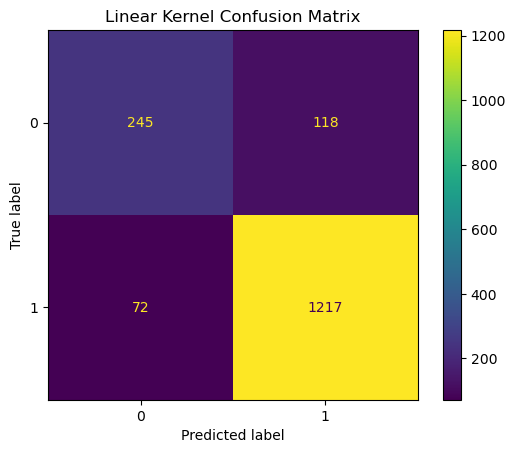


Polynomial Kernel Accuracy: 0.7803
Polynomial Confusion Matrix:
[[   0  363]
 [   0 1289]]


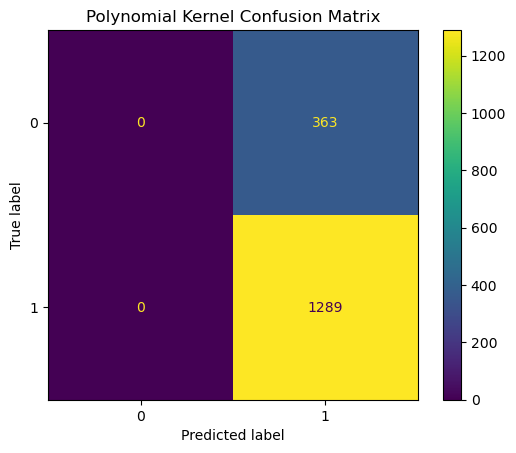


RBF Kernel Accuracy: 0.8747
RBF Confusion Matrix:
[[ 209  154]
 [  53 1236]]


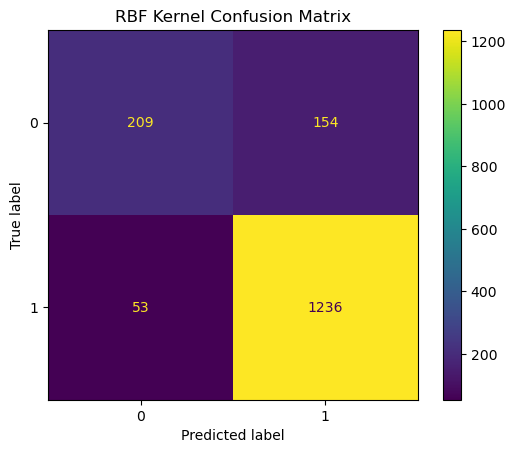


Feature importance from Linear SVM:
             Feature  Importance
2        Sleep_Hours    0.001667
5  Physical_Activity    0.194221
4  Tutoring_Sessions    0.522711
3    Previous_Scores    0.527870
0      Hours_Studied    1.333292
1         Attendance    1.800056


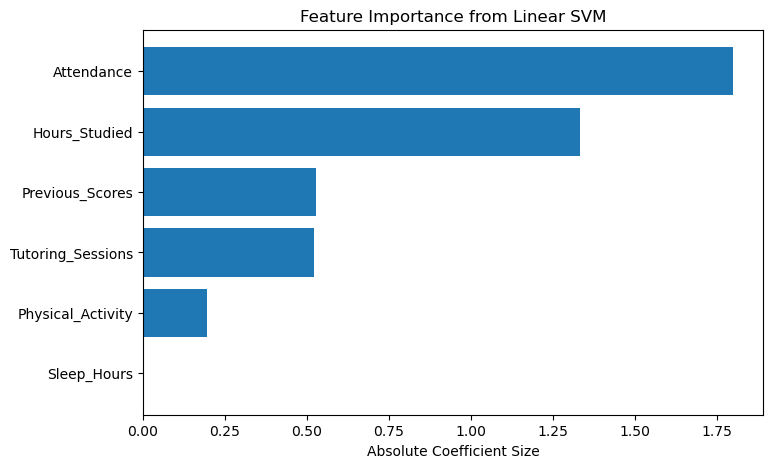

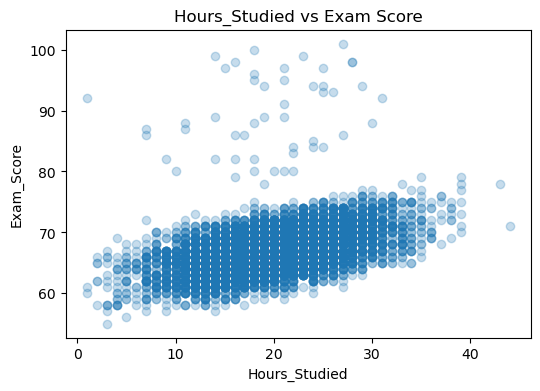

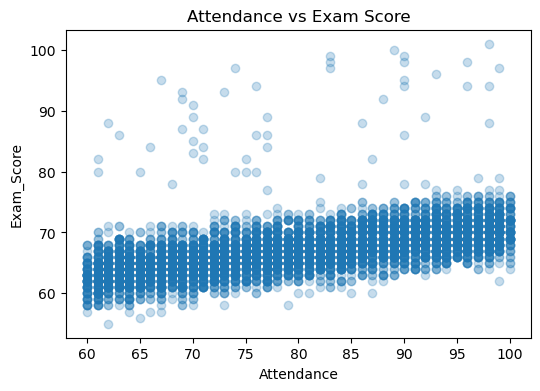

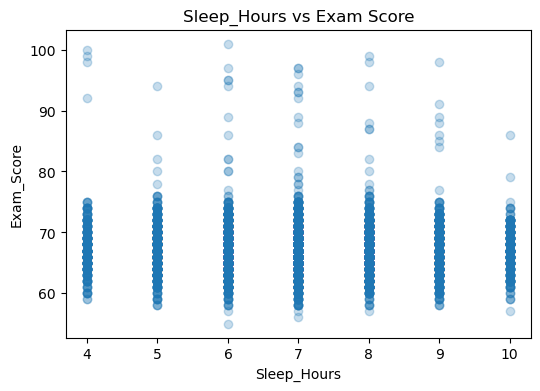

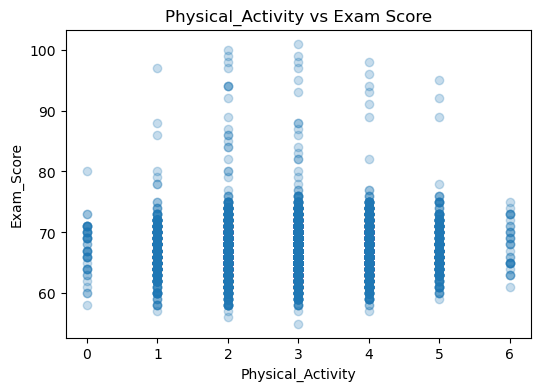

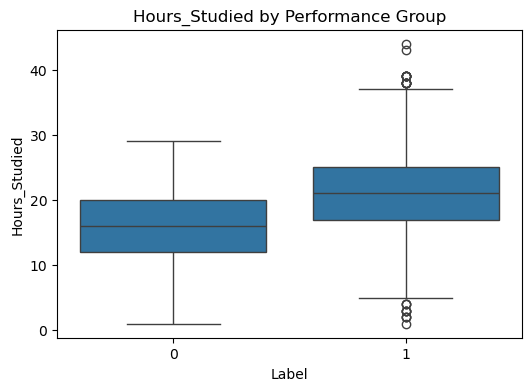

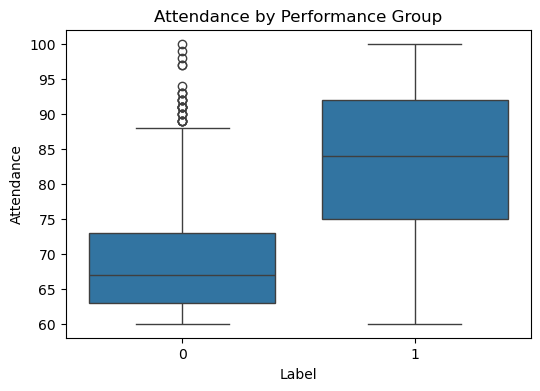

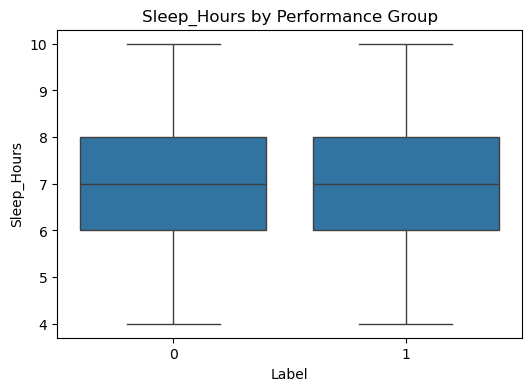

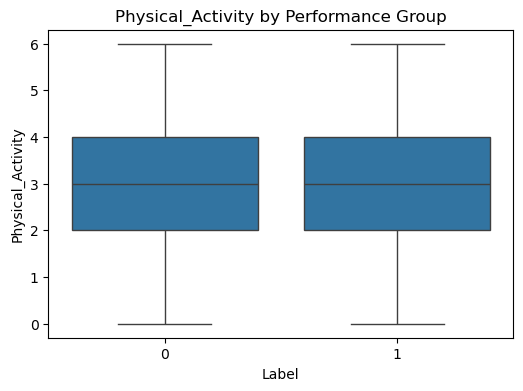


Rows used in 2D plot: 6607


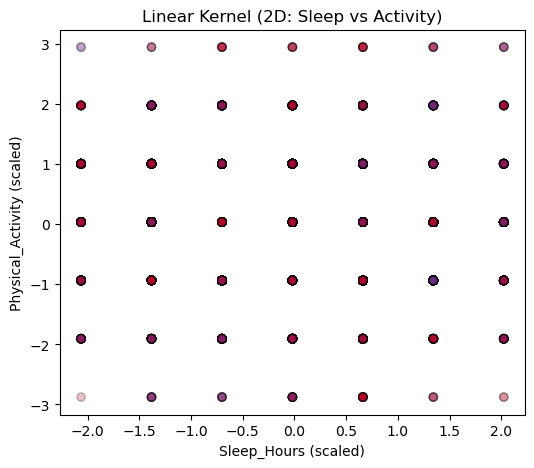

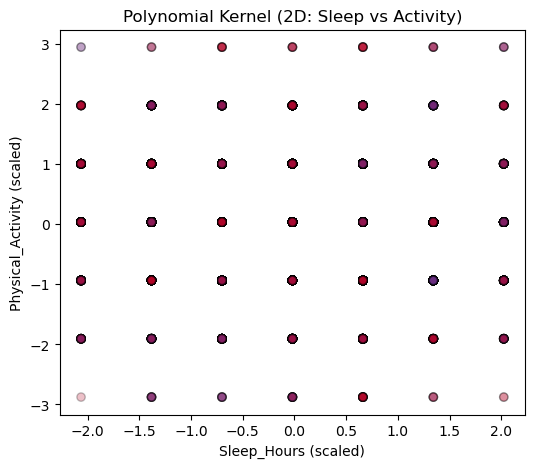

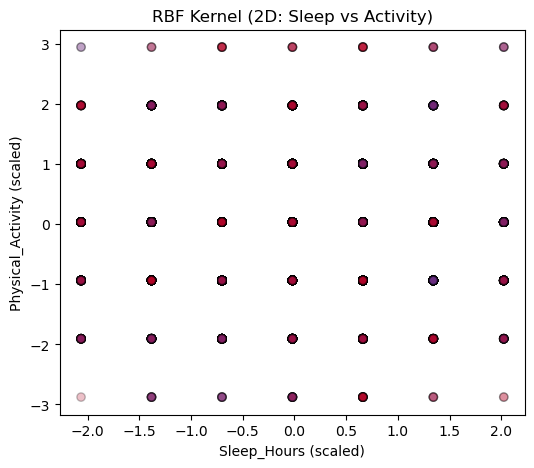

Rows used in 3D plot: 6607


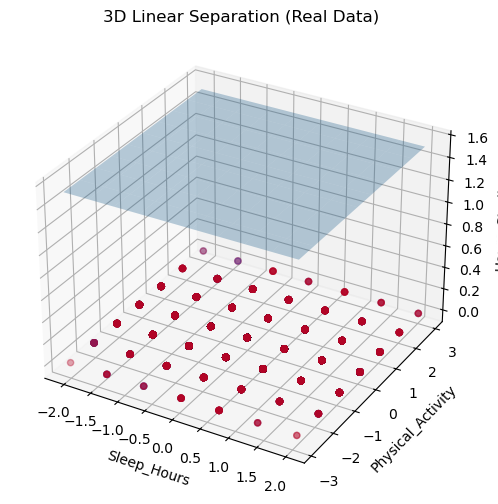

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from mpl_toolkits.mplot3d import Axes3D


# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv("dataset1_cleaned_numeric.csv")

print("Full dataset shape:", df.shape)
print(df.head())

# Create classification label
df["Label"] = (df["Exam_Score"] >= 65).astype(int)

print("\nPass/Fail threshold: 65")

print("\nLabel counts:")
print(df["Label"].value_counts())

print("\nModified dataset: \n", df.head(5), "\n") 
# ==============================
# 2. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


# ==============================
# 3. FEATURES FOR SVM
# ==============================
features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

X = df[features]
y = df["Label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nX_train shape:", X_train.shape, "\n Train Dataset: ", X_train.head(5), "\n")
print("X_test shape:", X_test.shape, "\n Train Dataset: ", X_train.head(5), "\n")

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# 4. SVM MODELS
# ==============================
models = {
    "Linear": SVC(kernel="linear", C=0.1),
    "Polynomial": SVC(kernel="poly", degree=2, C=0.01),
    "RBF": SVC(kernel="rbf", C=0.1)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    print(f"\n{name} Kernel Accuracy: {acc:.4f}")

    cm = confusion_matrix(y_test, preds)
    print(f"{name} Confusion Matrix:\n{cm}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Kernel Confusion Matrix")
    plt.show()


# ==============================
# 5. FEATURE IMPORTANCE
#    (Linear SVM only)
# ==============================
linear_model = SVC(kernel="linear", C=0.1)
linear_model.fit(X_train_scaled, y_train)

importance = np.abs(linear_model.coef_[0])

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=True)

print("\nFeature importance from Linear SVM:")
print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Absolute Coefficient Size")
plt.title("Feature Importance from Linear SVM")
plt.show()


# ==============================
# 6. SCATTER PLOTS VS EXAM SCORE
# ==============================
compare_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Physical_Activity"
]

for f in compare_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[f], df["Exam_Score"], alpha=0.25)
    plt.xlabel(f)
    plt.ylabel("Exam_Score")
    plt.title(f"{f} vs Exam Score")
    plt.show()


# ==============================
# 7. BOXPLOTS BY PERFORMANCE GROUP
# ==============================
for f in compare_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Label", y=f, data=df)
    plt.title(f"{f} by Performance Group")
    plt.show()


# ==============================
# 8. 2D VISUALIZATION (REAL DATA)
# ==============================
X2 = df[["Sleep_Hours", "Physical_Activity"]].values
y2 = df["Label"].values

print("\nRows used in 2D plot:", len(X2))

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

models2D = {
    "Linear": SVC(kernel="linear", C=0.1),
    "Polynomial": SVC(kernel="poly", degree=2, C=0.01),
    "RBF": SVC(kernel="rbf", C=0.1)
}

for name, model in models2D.items():
    model.fit(X2_scaled, y2)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        X2_scaled[:, 0],
        X2_scaled[:, 1],
        c=y2,
        cmap="coolwarm",
        edgecolors="k",
        alpha=0.25
    )

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0], colors="black")

    plt.title(f"{name} Kernel (2D: Sleep vs Activity)")
    plt.xlabel("Sleep_Hours (scaled)")
    plt.ylabel("Physical_Activity (scaled)")
    plt.show()


# ==============================
# 9. 3D VISUALIZATION (REAL DATA)
# ==============================
X3 = df[["Sleep_Hours", "Physical_Activity", "Hours_Studied"]].values
y3 = df["Label"].values

print("Rows used in 3D plot:", len(X3))

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

model3d = SVC(kernel="linear", C=0.1)
model3d.fit(X3_scaled, y3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X3_scaled[:, 0],
    X3_scaled[:, 1],
    X3_scaled[:, 2],
    c=y3,
    cmap="coolwarm",
    alpha=0.35
)

w = model3d.coef_[0]
b = model3d.intercept_[0]

xx, yy = np.meshgrid(
    np.linspace(X3_scaled[:, 0].min(), X3_scaled[:, 0].max(), 10),
    np.linspace(X3_scaled[:, 1].min(), X3_scaled[:, 1].max(), 10)
)

zz = (-w[0] * xx - w[1] * yy - b) / w[2]

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_xlabel("Sleep_Hours")
ax.set_ylabel("Physical_Activity")
ax.set_zlabel("Hours_Studied")
plt.title("3D Linear Separation (Real Data)")
plt.show()